In [1]:
# ============================================
# CELL 1: Mount Google Drive & Setup
# ============================================
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:

# Create workspace
!mkdir -p /content/ensemble_leaf_classification
!mkdir -p /content/ensemble_leaf_classification/checkpoints
!mkdir -p /content/ensemble_leaf_classification/logs

import os
os.chdir('/content/ensemble_leaf_classification')

print("✓ Workspace created")

✓ Workspace created


In [3]:
# ============================================
# CELL 2: Install Dependencies
# ============================================
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q opencv-python-headless pillow numpy pandas scikit-learn tqdm matplotlib seaborn gspread google-auth

print("✓ All packages installed")

✓ All packages installed


In [4]:
# ============================================
# CELL 3: Configuration
# ============================================
import torch
import numpy as np
import random

class Config:
    # Paths
    IMAGE_DATASET_PATH = "/content/drive/MyDrive/Refine_Dataset"  # CHANGE THIS
    #GOOGLE_SHEET_NAME = "Leaf_Measurements"  # Your Google Sheet name
    #GOOGLE_SHEET_RANGE = "Sheet1!A:C"  # Columns: Class, Length, Width

    # Model parameters
    NUM_CLASSES = 30
    INPUT_SIZE = 224
    BATCH_SIZE = 64
    NUM_EPOCHS_IMAGE = 100
    LEARNING_RATE_IMAGE = 0.01

    # Numerical model parameters
    NUMERICAL_FEATURES = 2  # Length and Width
    NUMERICAL_HIDDEN_SIZE = [16, 32, 16]  # MLP hidden layers

    # Ensemble parameters
    IMAGE_WEIGHT = 0.5  # Weight for image model (0-1)
    NUMERICAL_WEIGHT = 0.5  # Weight for numerical model (1 - IMAGE_WEIGHT)

    # Training
    NUM_WORKERS = 2
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

    # Checkpointing
    SAVE_DIR = "/content/ensemble_leaf_classification/checkpoints"

    def __init__(self):
        # Ensure weights sum to 1
        assert abs(self.IMAGE_WEIGHT + self.NUMERICAL_WEIGHT - 1.0) < 1e-6, "Weights must sum to 1"

config = Config()

# Set seed
random.seed(config.SEED)
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)

print(f"✓ Configuration loaded")
print(f"✓ Device: {config.DEVICE}")
print(f"✓ Ensemble weights: Image={config.IMAGE_WEIGHT}, Numerical={config.NUMERICAL_WEIGHT}")

✓ Configuration loaded
✓ Device: cuda
✓ Ensemble weights: Image=0.5, Numerical=0.5


In [5]:
# ============================================
# CELL 4 (UPDATED): Load Numerical Data (100 rows per class)
# ============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from google.colab import files
from sklearn.model_selection import train_test_split

def load_numerical_data_from_csv():
    """Load length and width data (100 rows per species)"""

    print("📁 Please upload your leaf_measurements.csv file")
    print("CSV should have 3000 rows (100 per species) with columns: Class, Length, Width")

    uploaded = files.upload()

    for filename in uploaded.keys():
        df = pd.read_csv(filename)
        print(f"✓ Loaded {filename}")
        print(f"   Total rows: {len(df)}")
        break

    # Verify columns
    required_columns = ['Class', 'Length', 'Width']
    for col in required_columns:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    # Check rows per class
    rows_per_class = df.groupby('Class').size()
    print(f"\n📊 Rows per species:")
    for species, count in rows_per_class.items():
        print(f"   {species}: {count} rows")

    # Create features and labels
    class_names = df['Class'].values
    lengths = df['Length'].astype(float).values
    widths = df['Width'].astype(float).values

    # Create feature matrix
    numerical_features = np.column_stack([lengths, widths])

    # Create label mapping
    unique_classes = df['Class'].unique()
    class_to_idx = {cls: idx for idx, cls in enumerate(unique_classes)}
    labels = np.array([class_to_idx[cls] for cls in class_names])

    # Standardize features
    scaler = StandardScaler()
    numerical_features_scaled = scaler.fit_transform(numerical_features)

    print(f"\n✓ Numerical data loaded:")
    print(f"   Total samples: {len(numerical_features_scaled)}")
    print(f"   Number of species: {len(unique_classes)}")
    print(f"   Features per sample: {numerical_features_scaled.shape[1]} (Length, Width)")
    print(f"   Features shape: {numerical_features_scaled.shape}")
    print(f"   Labels shape: {labels.shape}")

    # Show statistics
    print(f"\n📊 Feature statistics (original scale):")
    print(f"   Length - Mean: {lengths.mean():.2f}cm, Std: {lengths.std():.2f}cm")
    print(f"   Width  - Mean: {widths.mean():.2f}cm, Std: {widths.std():.2f}cm")

    return numerical_features_scaled, labels, class_to_idx, scaler, df

# Load data
numerical_features, numerical_labels, class_to_idx, scaler, df = load_numerical_data_from_csv()

# Split numerical data for training (will be matched with images)
print(f"\n✓ Class mapping created for {len(class_to_idx)} species")
print(f"   Example mapping: {list(class_to_idx.items())[:5]}")

📁 Please upload your leaf_measurements.csv file
CSV should have 3000 rows (100 per species) with columns: Class, Length, Width


Saving Updated with augmented data Numeric_Medicinal_Plant_Data.csv to Updated with augmented data Numeric_Medicinal_Plant_Data.csv
✓ Loaded Updated with augmented data Numeric_Medicinal_Plant_Data.csv
   Total rows: 300

📊 Rows per species:
   1.Tulshi: 10 rows
   10.Jolpai: 10 rows
   11.Neem: 10 rows
   12.Joba: 10 rows
   13.Telakucha: 10 rows
   14.Noyontara: 10 rows
   15.Bongada: 10 rows
   16.Boroi: 10 rows
   17.Horitoki: 10 rows
   18.Mehedi: 10 rows
   19.Aorhor: 10 rows
   2.Pathorkuchi: 10 rows
   20.Pudina: 10 rows
   21.Thankuni: 10 rows
   22.Paharipata: 10 rows
   23.Lemon: 10 rows
   24.Dhutra: 10 rows
   25.Raktapata: 10 rows
   26.Akondo: 10 rows
   27.Karipata: 10 rows
   28.Oporajita: 10 rows
   29.Hasnahena: 10 rows
   3.Bashok: 10 rows
   30.Orjun: 10 rows
   4.Hatishur: 10 rows
   5.Goolmorich: 10 rows
   6.Togor: 10 rows
   7.Daruchini: 10 rows
   8.Tejpata: 10 rows
   9.Sofeda: 10 rows

✓ Numerical data loaded:
   Total samples: 300
   Number of species: 30
 

In [6]:
# ============================================
# CELL 5 (UPDATED): Image Dataset with Matching Numerical Features
# ============================================
import cv2
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torch
import pandas as pd

class LeafDatasetWithNumerical(Dataset):
    """Dataset that matches each image with its corresponding numerical features"""

    def __init__(self, root_dir, numerical_df, class_to_idx, is_train=True):
        self.root_dir = root_dir
        self.numerical_df = numerical_df
        self.class_to_idx = class_to_idx
        self.is_train = is_train

        # Create reverse mapping
        self.idx_to_class = {v: k for k, v in class_to_idx.items()}

        # Load all image paths with their numerical features
        self.samples = []
        self._load_samples()

        # Setup transforms
        if is_train:
            self.transform = transforms.Compose([
                transforms.RandomResizedCrop(config.INPUT_SIZE, scale=(0.6, 1.0)),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomRotation(20),
                transforms.ColorJitter(brightness=0.2, contrast=0.3),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((config.INPUT_SIZE, config.INPUT_SIZE)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])

    def _load_samples(self):
        """Load all images and match with numerical features from the same class"""

        # Get all class folders
        class_folders = [d for d in os.listdir(self.root_dir)
                        if os.path.isdir(os.path.join(self.root_dir, d))]

        for class_name in class_folders:
            if class_name not in self.class_to_idx:
                print(f"⚠️ Warning: {class_name} not in numerical data, skipping")
                continue

            class_idx = self.class_to_idx[class_name]
            class_path = os.path.join(self.root_dir, class_name)

            # Get all numerical samples for this class
            class_numerical_data = self.numerical_df[self.numerical_df['Class'] == class_name]

            # Get all images in this class folder
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

            print(f"   {class_name}: {len(images)} images, {len(class_numerical_data)} numerical samples")

            # Match each image with a numerical sample (cycle if more images than numerical samples)
            for img_idx, img_file in enumerate(images):
                img_path = os.path.join(class_path, img_file)

                # Get corresponding numerical sample (cycle through available samples)
                numerical_idx = img_idx % len(class_numerical_data)
                numerical_sample = class_numerical_data.iloc[numerical_idx]

                numerical_features = np.array([
                    numerical_sample['Length'],
                    numerical_sample['Width']
                ])

                self.samples.append({
                    'image_path': img_path,
                    'label': class_idx,
                    'numerical_features': numerical_features
                })

        print(f"\n✓ Loaded {len(self.samples)} image-numerical pairs")

        # Verify counts
        labels_count = pd.Series([s['label'] for s in self.samples]).value_counts()
        print(f"   Samples per class: {dict(sorted(labels_count.items()))}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load and transform image
        image = Image.open(sample['image_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Get numerical features
        numerical_feat = torch.tensor(sample['numerical_features'], dtype=torch.float32)

        # Get label
        label = sample['label']

        return image, numerical_feat, label

def create_dataloaders():
    """Create train, validation, and test dataloaders"""

    # Check if data is already split
    train_path = os.path.join(config.IMAGE_DATASET_PATH, 'train')
    val_path = os.path.join(config.IMAGE_DATASET_PATH, 'val')
    test_path = os.path.join(config.IMAGE_DATASET_PATH, 'test')

    if os.path.exists(train_path) and os.path.exists(val_path):
        print("📁 Using existing train/val/test split")
        train_dataset = LeafDatasetWithNumerical(train_path, df, class_to_idx, is_train=True)
        val_dataset = LeafDatasetWithNumerical(val_path, df, class_to_idx, is_train=False)
        test_dataset = LeafDatasetWithNumerical(test_path, df, class_to_idx, is_train=False)
    else:
        print("📁 Creating train/val/test split (70/15/15)")
        # Load all samples
        full_dataset = LeafDatasetWithNumerical(config.IMAGE_DATASET_PATH, df, class_to_idx, is_train=True)

        # Split indices
        total_size = len(full_dataset)
        train_size = int(0.7 * total_size)
        val_size = int(0.15 * total_size)
        test_size = total_size - train_size - val_size

        train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
            full_dataset, [train_size, val_size, test_size]
        )
        print(f"   Train: {train_size}, Val: {val_size}, Test: {test_size}")

    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,
                              num_workers=config.NUM_WORKERS, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                            num_workers=config.NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                             num_workers=config.NUM_WORKERS, pin_memory=True)

    return train_loader, val_loader, test_loader

# Create dataloaders
print("\n📊 Creating dataloaders...")
train_loader, val_loader, test_loader = create_dataloaders()


📊 Creating dataloaders...
📁 Creating train/val/test split (70/15/15)
   9.Sofeda: 100 images, 10 numerical samples
   7.Daruchini: 100 images, 10 numerical samples
   8.Tejpata: 100 images, 10 numerical samples
   5.Goolmorich: 100 images, 10 numerical samples
   4.Hatishur: 100 images, 10 numerical samples
   6.Togor: 100 images, 10 numerical samples
   30.Orjun: 100 images, 10 numerical samples
   3.Bashok: 100 images, 10 numerical samples
   29.Hasnahena: 100 images, 10 numerical samples
   26.Akondo: 100 images, 10 numerical samples
   27.Karipata: 100 images, 10 numerical samples
   28.Oporajita: 100 images, 10 numerical samples
   25.Raktapata: 100 images, 10 numerical samples
   23.Lemon: 100 images, 10 numerical samples
   24.Dhutra: 100 images, 10 numerical samples
   22.Paharipata: 100 images, 10 numerical samples
   21.Thankuni: 100 images, 10 numerical samples
   19.Aorhor: 100 images, 10 numerical samples
   18.Mehedi: 100 images, 10 numerical samples
   20.Pudina: 100 im

In [7]:
# ============================================
# CELL 6: Texture-Only Image Model (ResNet50 Layers 1&2)
# ============================================
import torch.nn as nn
import torchvision.models as models

class TextureOnlyImageModel(nn.Module):
    """ResNet50 using only layers 1&2 for texture features"""

    def __init__(self, num_classes=30):
        super().__init__()
        backbone = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # Take only first 2 layers (texture detectors)
        self.texture_features = nn.Sequential(
            backbone.conv1,
            backbone.bn1,
            backbone.relu,
            backbone.maxpool,
            backbone.layer1,
            backbone.layer2,
        )

        # Global pooling and classifier
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(512, num_classes)  # 512 from layer2

    def forward(self, x):
        # Extract texture features
        features = self.texture_features(x)
        pooled = self.pool(features)
        flattened = pooled.flatten(1)
        output = self.classifier(flattened)
        return output

# Initialize image model
image_model = TextureOnlyImageModel(num_classes=config.NUM_CLASSES)
image_model = image_model.to(config.DEVICE)

print("✓ Texture-Only Image Model Ready")
print(f"   Total parameters: {sum(p.numel() for p in image_model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


✓ Texture-Only Image Model Ready
   Total parameters: 1,460,318


In [8]:
# ============================================
# CELL 7: Numerical Model (MLP for Length & Width)
# ============================================
class NumericalMLP(nn.Module):
    """MLP for numerical features (length & width)"""

    def __init__(self, input_size=2, hidden_sizes=[16, 32, 16], output_size=30):
        super().__init__()

        layers = []
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, output_size))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Alternative: Random Forest (non-neural network option)
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize

class NumericalRandomForest:
    """Random Forest wrapper for numerical features"""

    def __init__(self, n_estimators=100, max_depth=10):
        self.model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=config.SEED
        )
        self.is_fitted = False

    def fit(self, X, y):
        self.model.fit(X, y)
        self.is_fitted = True

    def predict_proba(self, X):
        if not self.is_fitted:
            raise ValueError("Model not fitted yet")
        return self.model.predict_proba(X)

    def predict(self, X):
        if not self.is_fitted:
            raise ValueError("Model not fitted yet")
        return self.model.predict(X)

# Initialize numerical model (choose one)
USE_MLP = True  # Set False to use Random Forest

if USE_MLP:
    numerical_model = NumericalMLP(
        input_size=config.NUMERICAL_FEATURES,
        hidden_sizes=config.NUMERICAL_HIDDEN_SIZE,
        output_size=config.NUM_CLASSES
    ).to(config.DEVICE)
    print("✓ Numerical MLP Model Ready")
else:
    numerical_model = NumericalRandomForest(n_estimators=100, max_depth=10)
    print("✓ Numerical Random Forest Model Ready")

✓ Numerical MLP Model Ready


In [9]:
# ============================================
# CELL 8: Ensemble Model (Weighted Combination)
# ============================================
class EnsembleModel(nn.Module):
    """Ensemble of Image and Numerical models with configurable weights"""

    def __init__(self, image_model, numerical_model, image_weight=0.5, numerical_weight=0.5):
        super().__init__()
        self.image_model = image_model
        self.numerical_model = numerical_model
        self.image_weight = image_weight
        self.numerical_weight = numerical_weight
        self.use_mlp = isinstance(numerical_model, NumericalMLP)

    def forward(self, image, numerical_features):
        # Get predictions from both models
        image_logits = self.image_model(image)

        if self.use_mlp:
            numerical_logits = self.numerical_model(numerical_features)
        else:
            # For Random Forest, we need to handle differently
            numerical_logits = torch.tensor(
                self.numerical_model.predict_proba(numerical_features.cpu().numpy()),
                device=image.device
            )

        # Weighted combination
        final_logits = (self.image_weight * image_logits +
                       self.numerical_weight * numerical_logits)

        return final_logits

    def set_weights(self, image_weight, numerical_weight):
        """Adjust ensemble weights dynamically"""
        self.image_weight = image_weight
        self.numerical_weight = numerical_weight
        print(f"✓ Ensemble weights updated: Image={image_weight}, Numerical={numerical_weight}")

# Initialize ensemble
ensemble_model = EnsembleModel(
    image_model=image_model,
    numerical_model=numerical_model,
    image_weight=config.IMAGE_WEIGHT,
    numerical_weight=config.NUMERICAL_WEIGHT
)
ensemble_model = ensemble_model.to(config.DEVICE)

print(f"✓ Ensemble Model Ready")
print(f"   Image weight: {config.IMAGE_WEIGHT}")
print(f"   Numerical weight: {config.NUMERICAL_WEIGHT}")

✓ Ensemble Model Ready
   Image weight: 0.5
   Numerical weight: 0.5



🚀 Training Ensemble Model
Device: cuda
Epochs: 100
Ensemble weights: Image=0.5, Numerical=0.5



Epoch 1/100 [Val]: 100%|██████████| 8/8 [02:30<00:00, 18.83s/it, loss=7.07]


🎉 New best validation accuracy: 0.0556

📊 Epoch 1/100
   Train - Loss: 3.2188, Acc: 0.0967
   Val   - Loss: 7.8242, Acc: 0.0556
   Best Val Acc: 0.0556



Epoch 2/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.24it/s, loss=2.86]


🎉 New best validation accuracy: 0.1422

📊 Epoch 2/100
   Train - Loss: 2.9225, Acc: 0.1562
   Val   - Loss: 3.4630, Acc: 0.1422
   Best Val Acc: 0.1422



...

🎉 New best validation accuracy: 0.3511

📊 Epoch 8/100
   Train - Loss: 2.1842, Acc: 0.3433
   Val   - Loss: 2.0891, Acc: 0.3511
   Best Val Acc: 0.3511



Epoch 9/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.89it/s, loss=2.03]



📊 Epoch 9/100
   Train - Loss: 2.0417, Acc: 0.3871
   Val   - Loss: 2.9435, Acc: 0.2511
   Best Val Acc: 0.3511



Epoch 10/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.87it/s, loss=1.18]



📊 Epoch 10/100
   Train - Loss: 1.9561, Acc: 0.4062
   Val   - Loss: 2.1273, Acc: 0.3156
   Best Val Acc: 0.3511



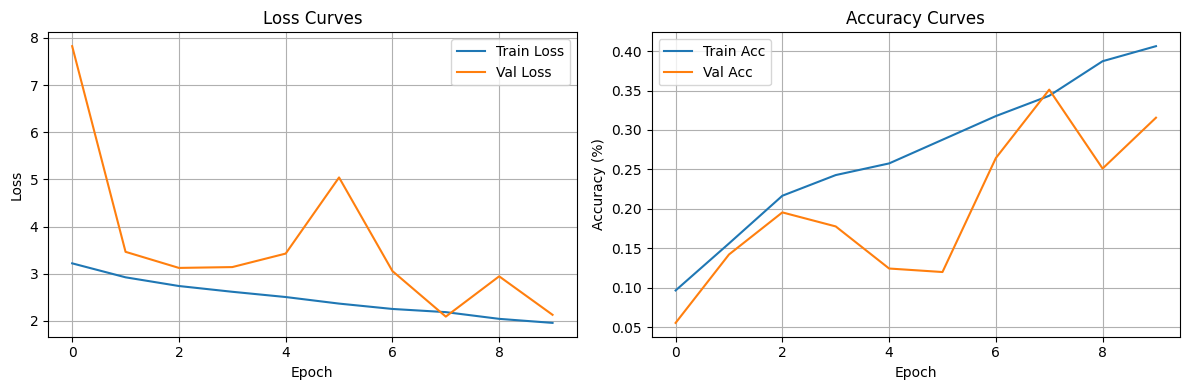

Epoch 11/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.86it/s, loss=0.697]



📊 Epoch 11/100
   Train - Loss: 1.8943, Acc: 0.4219
   Val   - Loss: 2.5042, Acc: 0.3044
   Best Val Acc: 0.3511



Epoch 12/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.85it/s, loss=0.82]



📊 Epoch 12/100
   Train - Loss: 1.7080, Acc: 0.4762
   Val   - Loss: 2.9474, Acc: 0.2911
   Best Val Acc: 0.3511



Epoch 13/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.87it/s, loss=1.22]


...

🎉 New best validation accuracy: 0.5156

📊 Epoch 18/100
   Train - Loss: 1.1551, Acc: 0.6581
   Val   - Loss: 1.4388, Acc: 0.5156
   Best Val Acc: 0.5156



Epoch 19/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.25it/s, loss=1.54]


🎉 New best validation accuracy: 0.5444

📊 Epoch 19/100
   Train - Loss: 1.1288, Acc: 0.6429
   Val   - Loss: 1.6017, Acc: 0.5444
   Best Val Acc: 0.5444



Epoch 20/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.30it/s, loss=1.98]



📊 Epoch 20/100
   Train - Loss: 1.0615, Acc: 0.6652
   Val   - Loss: 5.9280, Acc: 0.2044
   Best Val Acc: 0.5444



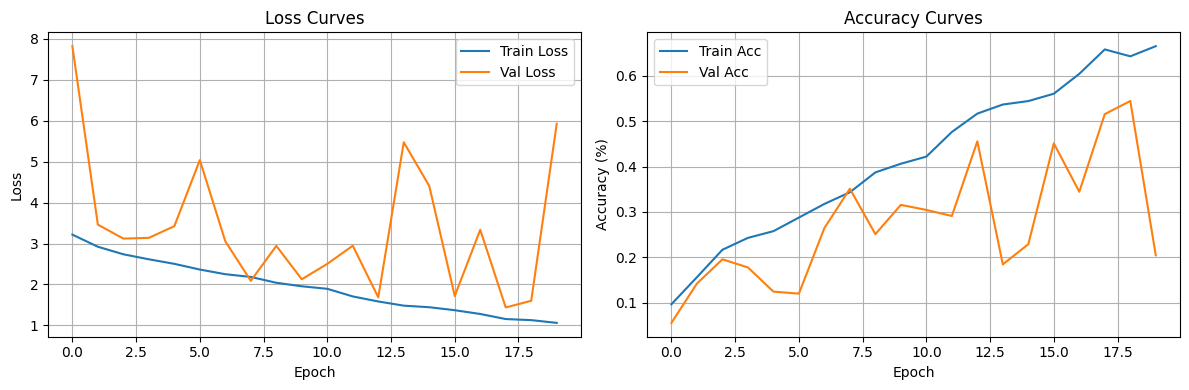

Epoch 21/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.26it/s, loss=1.64]



📊 Epoch 21/100
   Train - Loss: 0.9656, Acc: 0.7019
   Val   - Loss: 2.5315, Acc: 0.4400
   Best Val Acc: 0.5444



Epoch 22/100 [Val]: 100%|██████████| 8/8 [00:05<00:00,  1.41it/s, loss=2.92]



📊 Epoch 22/100
   Train - Loss: 1.0294, Acc: 0.6700
   Val   - Loss: 2.2609, Acc: 0.5000
   Best Val Acc: 0.5444



Epoch 23/100 [Val]: 100%|██████████| 8/8 [00:05<00:00,  1.42it/s, loss=1.26]


...


📊 Epoch 28/100
   Train - Loss: 0.7566, Acc: 0.7638
   Val   - Loss: 1.6847, Acc: 0.5356
   Best Val Acc: 0.6889



Epoch 29/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.85it/s, loss=0.158]



📊 Epoch 29/100
   Train - Loss: 0.7299, Acc: 0.7819
   Val   - Loss: 1.0539, Acc: 0.6489
   Best Val Acc: 0.6889



Epoch 30/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.86it/s, loss=0.356]



📊 Epoch 30/100
   Train - Loss: 0.6550, Acc: 0.7943
   Val   - Loss: 0.8846, Acc: 0.6889
   Best Val Acc: 0.6889



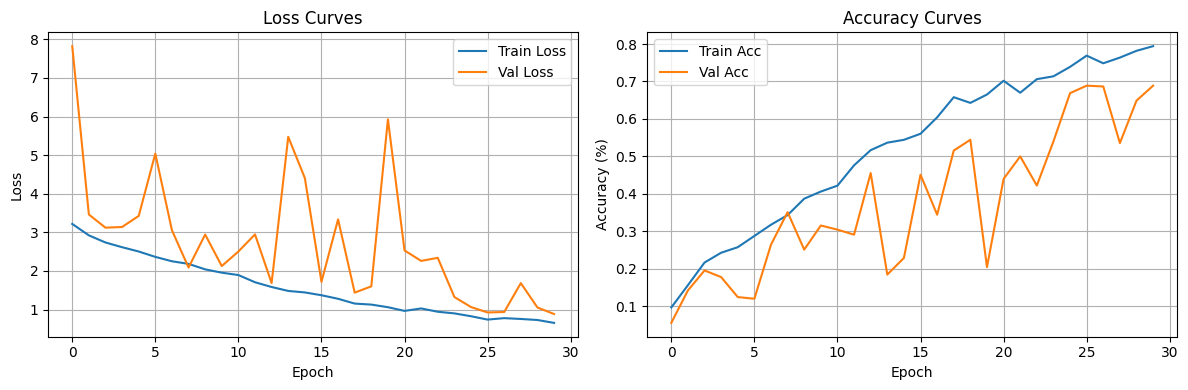

Epoch 31/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.85it/s, loss=0.67]



📊 Epoch 31/100
   Train - Loss: 0.6921, Acc: 0.7795
   Val   - Loss: 2.1315, Acc: 0.4489
   Best Val Acc: 0.6889



Epoch 32/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.87it/s, loss=0.312]


🎉 New best validation accuracy: 0.7222

📊 Epoch 32/100
   Train - Loss: 0.6757, Acc: 0.7829
   Val   - Loss: 0.8707, Acc: 0.7222
   Best Val Acc: 0.7222



Epoch 33/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.84it/s, loss=0.42]


...


📊 Epoch 38/100
   Train - Loss: 0.5752, Acc: 0.8138
   Val   - Loss: 2.9626, Acc: 0.4244
   Best Val Acc: 0.7311



Epoch 39/100 [Val]: 100%|██████████| 8/8 [00:05<00:00,  1.34it/s, loss=1.76]



📊 Epoch 39/100
   Train - Loss: 0.5482, Acc: 0.8357
   Val   - Loss: 1.0291, Acc: 0.7089
   Best Val Acc: 0.7311



Epoch 40/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.22it/s, loss=0.213]



📊 Epoch 40/100
   Train - Loss: 0.5495, Acc: 0.8124
   Val   - Loss: 2.5280, Acc: 0.4689
   Best Val Acc: 0.7311



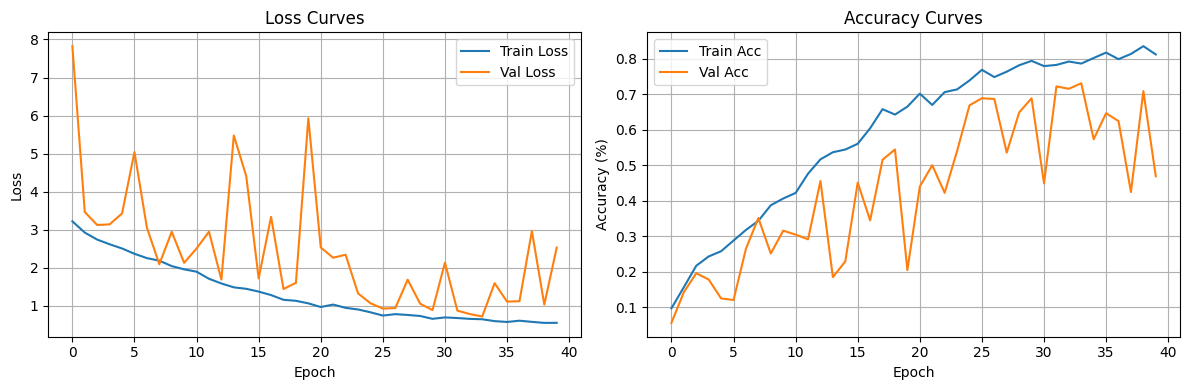

Epoch 41/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.21it/s, loss=0.0474]



📊 Epoch 41/100
   Train - Loss: 0.5134, Acc: 0.8381
   Val   - Loss: 0.9347, Acc: 0.6844
   Best Val Acc: 0.7311



Epoch 42/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.22it/s, loss=1.01]



📊 Epoch 42/100
   Train - Loss: 0.4889, Acc: 0.8400
   Val   - Loss: 1.8024, Acc: 0.5000
   Best Val Acc: 0.7311



Epoch 43/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.32it/s, loss=0.0233]


...


📊 Epoch 48/100
   Train - Loss: 0.4747, Acc: 0.8476
   Val   - Loss: 1.0453, Acc: 0.6444
   Best Val Acc: 0.8400



Epoch 49/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.84it/s, loss=1.4]



📊 Epoch 49/100
   Train - Loss: 0.4067, Acc: 0.8624
   Val   - Loss: 1.6942, Acc: 0.5467
   Best Val Acc: 0.8400



Epoch 50/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.84it/s, loss=0.00275]



📊 Epoch 50/100
   Train - Loss: 0.4159, Acc: 0.8624
   Val   - Loss: 0.4334, Acc: 0.8356
   Best Val Acc: 0.8400



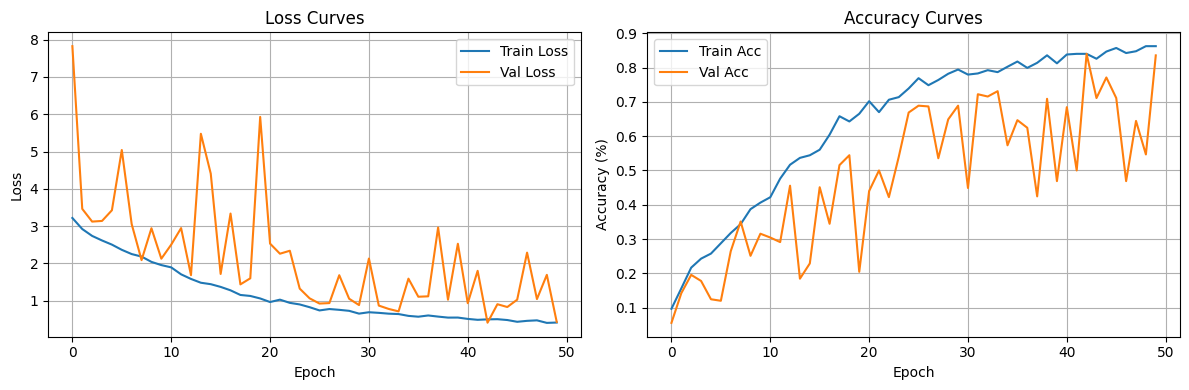

Epoch 51/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.84it/s, loss=0.0823]


🎉 New best validation accuracy: 0.8422

📊 Epoch 51/100
   Train - Loss: 0.3802, Acc: 0.8752
   Val   - Loss: 0.5079, Acc: 0.8422
   Best Val Acc: 0.8422



Epoch 52/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.86it/s, loss=0.00361]



📊 Epoch 52/100
   Train - Loss: 0.3931, Acc: 0.8738
   Val   - Loss: 0.5243, Acc: 0.7911
   Best Val Acc: 0.8422



Epoch 53/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.77it/s, loss=0.638]


...


📊 Epoch 58/100
   Train - Loss: 0.3544, Acc: 0.8924
   Val   - Loss: 0.8043, Acc: 0.7333
   Best Val Acc: 0.8422



Epoch 59/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.67it/s, loss=0.668]



📊 Epoch 59/100
   Train - Loss: 0.3441, Acc: 0.8914
   Val   - Loss: 1.2650, Acc: 0.6378
   Best Val Acc: 0.8422



Epoch 60/100 [Val]: 100%|██████████| 8/8 [00:05<00:00,  1.53it/s, loss=3.76]



📊 Epoch 60/100
   Train - Loss: 0.3037, Acc: 0.9010
   Val   - Loss: 3.9701, Acc: 0.3489
   Best Val Acc: 0.8422



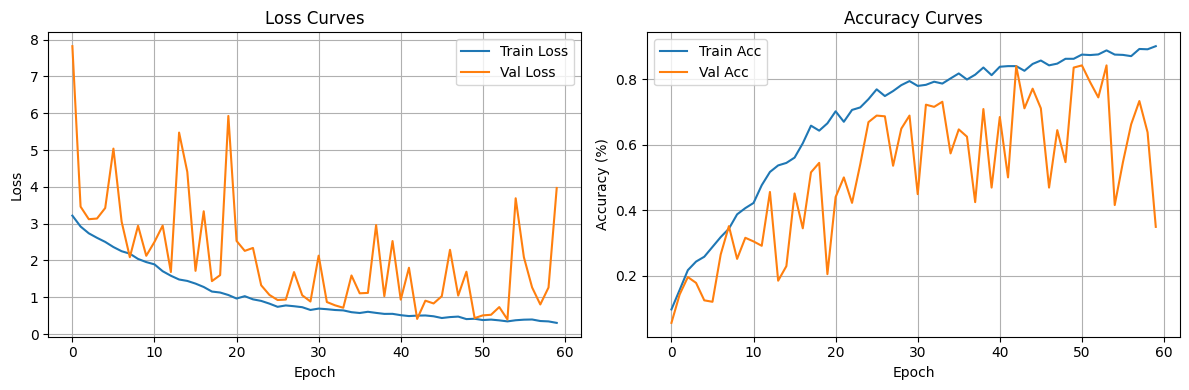

Epoch 61/100 [Val]: 100%|██████████| 8/8 [00:05<00:00,  1.51it/s, loss=0.359]



📊 Epoch 61/100
   Train - Loss: 0.3329, Acc: 0.8924
   Val   - Loss: 1.2246, Acc: 0.6511
   Best Val Acc: 0.8422



Epoch 62/100 [Val]: 100%|██████████| 8/8 [00:05<00:00,  1.39it/s, loss=0.00791]



📊 Epoch 62/100
   Train - Loss: 0.3269, Acc: 0.8886
   Val   - Loss: 0.6688, Acc: 0.7533
   Best Val Acc: 0.8422



Epoch 63/100 [Val]: 100%|██████████| 8/8 [00:05<00:00,  1.39it/s, loss=0.737]


...


📊 Epoch 68/100
   Train - Loss: 0.3027, Acc: 0.9005
   Val   - Loss: 0.7177, Acc: 0.7711
   Best Val Acc: 0.8622



Epoch 69/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.18it/s, loss=0.972]



📊 Epoch 69/100
   Train - Loss: 0.2770, Acc: 0.9081
   Val   - Loss: 3.2331, Acc: 0.4978
   Best Val Acc: 0.8622



Epoch 70/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.15it/s, loss=0.0028]



📊 Epoch 70/100
   Train - Loss: 0.2498, Acc: 0.9152
   Val   - Loss: 1.6702, Acc: 0.6467
   Best Val Acc: 0.8622



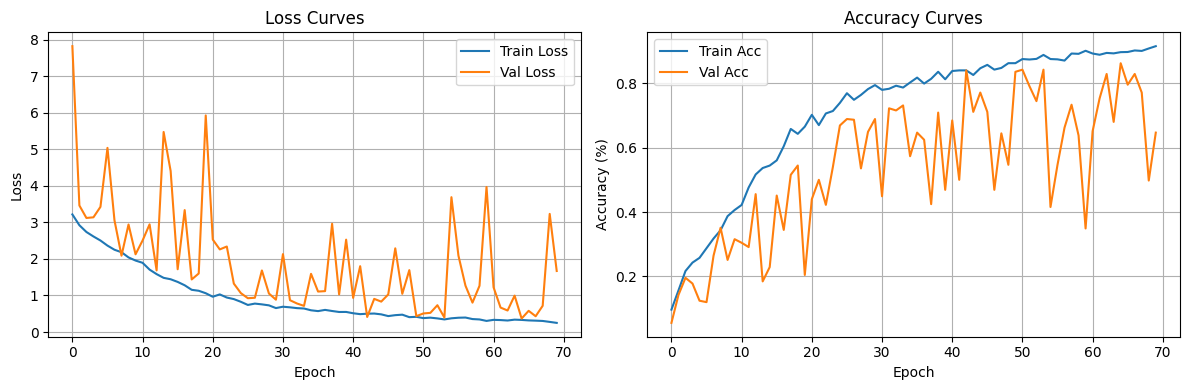

Epoch 71/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.17it/s, loss=0.211]



📊 Epoch 71/100
   Train - Loss: 0.2711, Acc: 0.9090
   Val   - Loss: 0.6365, Acc: 0.7689
   Best Val Acc: 0.8622



Epoch 72/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.19it/s, loss=1.35]



📊 Epoch 72/100
   Train - Loss: 0.2868, Acc: 0.9019
   Val   - Loss: 1.0139, Acc: 0.7222
   Best Val Acc: 0.8622



Epoch 73/100 [Val]: 100%|██████████| 8/8 [00:06<00:00,  1.28it/s, loss=0.668]


...


📊 Epoch 78/100
   Train - Loss: 0.2602, Acc: 0.9138
   Val   - Loss: 0.4640, Acc: 0.8533
   Best Val Acc: 0.8667



Epoch 79/100 [Val]: 100%|██████████| 8/8 [00:05<00:00,  1.52it/s, loss=0.536]



📊 Epoch 79/100
   Train - Loss: 0.3006, Acc: 0.9033
   Val   - Loss: 0.7682, Acc: 0.7667
   Best Val Acc: 0.8667



Epoch 80/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.65it/s, loss=0.0873]



📊 Epoch 80/100
   Train - Loss: 0.2680, Acc: 0.9162
   Val   - Loss: 0.7321, Acc: 0.7578
   Best Val Acc: 0.8667



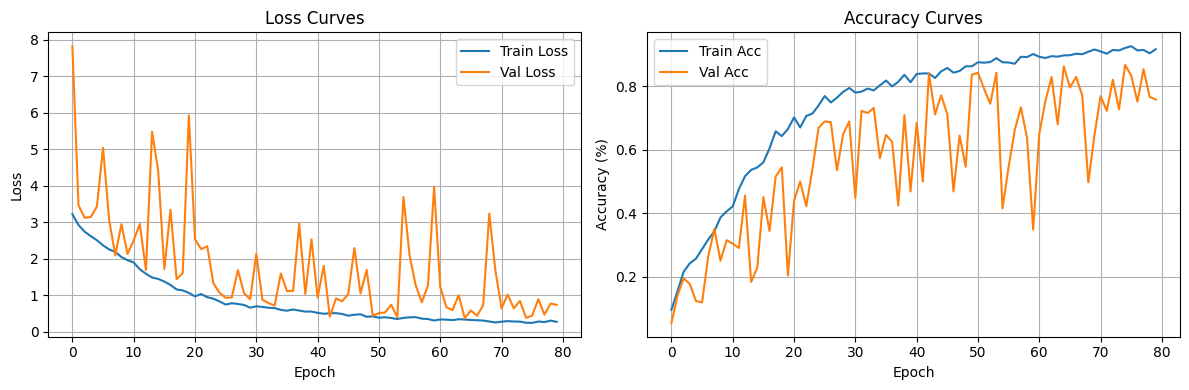

Epoch 81/100 [Val]: 100%|██████████| 8/8 [00:05<00:00,  1.60it/s, loss=0.031]



📊 Epoch 81/100
   Train - Loss: 0.2396, Acc: 0.9262
   Val   - Loss: 0.9973, Acc: 0.7133
   Best Val Acc: 0.8667



Epoch 82/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.68it/s, loss=0.00285]



📊 Epoch 82/100
   Train - Loss: 0.2382, Acc: 0.9205
   Val   - Loss: 0.5376, Acc: 0.8067
   Best Val Acc: 0.8667



Epoch 83/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.77it/s, loss=0.0678]


...


📊 Epoch 88/100
   Train - Loss: 0.1955, Acc: 0.9419
   Val   - Loss: 0.3852, Acc: 0.8667
   Best Val Acc: 0.8667



Epoch 89/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.79it/s, loss=0.0321]


🎉 New best validation accuracy: 0.9178

📊 Epoch 89/100
   Train - Loss: 0.2214, Acc: 0.9314
   Val   - Loss: 0.2495, Acc: 0.9178
   Best Val Acc: 0.9178



Epoch 90/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.81it/s, loss=0.000584]



📊 Epoch 90/100
   Train - Loss: 0.2258, Acc: 0.9271
   Val   - Loss: 0.3851, Acc: 0.8556
   Best Val Acc: 0.9178



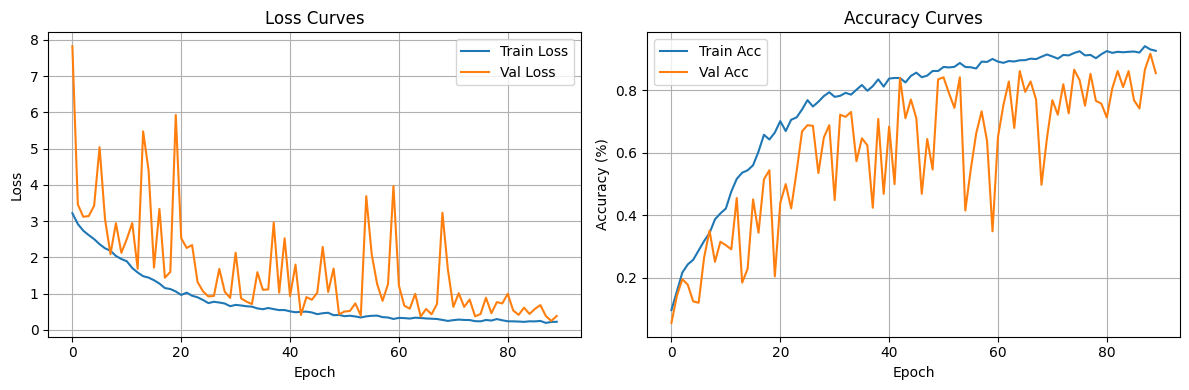

Epoch 91/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.76it/s, loss=0.161]



📊 Epoch 91/100
   Train - Loss: 0.1889, Acc: 0.9352
   Val   - Loss: 1.1362, Acc: 0.6711
   Best Val Acc: 0.9178



Epoch 92/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.81it/s, loss=0.0209]



📊 Epoch 92/100
   Train - Loss: 0.1697, Acc: 0.9471
   Val   - Loss: 0.3152, Acc: 0.8911
   Best Val Acc: 0.9178



Epoch 93/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.83it/s, loss=0.00954]


...


📊 Epoch 98/100
   Train - Loss: 0.1704, Acc: 0.9433
   Val   - Loss: 0.2404, Acc: 0.9000
   Best Val Acc: 0.9178



Epoch 99/100 [Val]: 100%|██████████| 8/8 [00:04<00:00,  1.74it/s, loss=0.11]


🎉 New best validation accuracy: 0.9200

📊 Epoch 99/100
   Train - Loss: 0.1586, Acc: 0.9505
   Val   - Loss: 0.2205, Acc: 0.9200
   Best Val Acc: 0.9200



Epoch 100/100 [Val]: 100%|██████████| 8/8 [00:07<00:00,  1.01it/s, loss=0.0134]



📊 Epoch 100/100
   Train - Loss: 0.1971, Acc: 0.9400
   Val   - Loss: 0.2735, Acc: 0.9000
   Best Val Acc: 0.9200



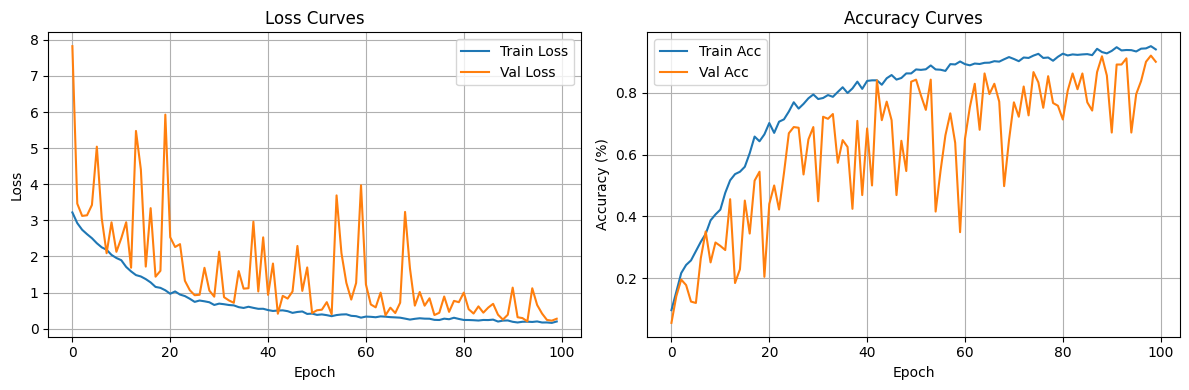


✅ Training Complete!
✓ Best validation accuracy: 0.9200


In [10]:
# ============================================
# CELL 9: Training Functions
# ============================================
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

class EnsembleTrainer:
    def __init__(self, ensemble_model, train_loader, val_loader):
        self.ensemble = ensemble_model
        self.train_loader = train_loader
        self.val_loader = val_loader

        # Separate optimizers for image and numerical models if using MLP
        self.optimizer_image = torch.optim.AdamW(
            ensemble_model.image_model.parameters(),
            lr=config.LEARNING_RATE_IMAGE,
            weight_decay=1e-4
        )

        if ensemble_model.use_mlp:
            self.optimizer_numerical = torch.optim.AdamW(
                ensemble_model.numerical_model.parameters(),
                lr=0.001,
                weight_decay=1e-4
            )
        else:
            self.optimizer_numerical = None

        self.criterion = nn.CrossEntropyLoss()

        # Metrics
        self.best_val_acc = 0
        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []
        self.start_epoch = 0

        self.load_checkpoint()

    def load_checkpoint(self):
        """Load checkpoint if exists"""
        checkpoint_path = os.path.join(config.SAVE_DIR, 'ensemble_checkpoint.pth')
        if os.path.exists(checkpoint_path):
            print("🔄 Loading checkpoint...")
            checkpoint = torch.load(checkpoint_path)
            self.ensemble.load_state_dict(checkpoint['ensemble_state_dict'])
            self.optimizer_image.load_state_dict(checkpoint['optimizer_image_state_dict'])
            if self.optimizer_numerical and 'optimizer_numerical_state_dict' in checkpoint:
                self.optimizer_numerical.load_state_dict(checkpoint['optimizer_numerical_state_dict'])
            self.start_epoch = checkpoint['epoch'] + 1
            self.best_val_acc = checkpoint['best_val_acc']
            self.train_losses = checkpoint.get('train_losses', [])
            self.val_losses = checkpoint.get('val_losses', [])
            self.train_accs = checkpoint.get('train_accs', [])
            self.val_accs = checkpoint.get('val_accs', [])
            print(f"✓ Resumed from epoch {self.start_epoch}")
            return True
        return False

    def save_checkpoint(self, epoch, is_best=False):
        """Save checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'ensemble_state_dict': self.ensemble.state_dict(),
            'optimizer_image_state_dict': self.optimizer_image.state_dict(),
            'best_val_acc': self.best_val_acc,
            'train_losses': self.train_losses,
            'val_losses': self.val_losses,
            'train_accs': self.train_accs,
            'val_accs': self.val_accs
        }

        if self.optimizer_numerical:
            checkpoint['optimizer_numerical_state_dict'] = self.optimizer_numerical.state_dict()

        torch.save(checkpoint, os.path.join(config.SAVE_DIR, 'ensemble_checkpoint.pth'))

        if is_best:
            torch.save(checkpoint, os.path.join(config.SAVE_DIR, 'ensemble_best.pth'))

    def train_epoch(self, epoch):
        self.ensemble.train()
        total_loss = 0
        all_preds = []
        all_labels = []

        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch+1}/{config.NUM_EPOCHS_IMAGE} [Train]')
        for images, numerical_feats, labels in pbar:
            images = images.to(config.DEVICE)
            numerical_feats = numerical_feats.to(config.DEVICE).float()
            labels = labels.to(config.DEVICE)

            # Zero gradients
            self.optimizer_image.zero_grad()
            if self.optimizer_numerical:
                self.optimizer_numerical.zero_grad()

            # Forward pass
            outputs = self.ensemble(images, numerical_feats)
            loss = self.criterion(outputs, labels)

            # Backward pass
            loss.backward()
            self.optimizer_image.step()
            if self.optimizer_numerical:
                self.optimizer_numerical.step()

            # Metrics
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Update progress bar
            current_acc = accuracy_score(all_labels[-32:], all_preds[-32:]) if len(all_preds) >= 32 else 0
            pbar.set_postfix({'loss': loss.item(), 'acc': f'{current_acc:.3f}'})

        avg_loss = total_loss / len(self.train_loader)
        accuracy = accuracy_score(all_labels, all_preds)

        self.train_losses.append(avg_loss)
        self.train_accs.append(accuracy)

        return avg_loss, accuracy

    def validate(self, epoch):
        self.ensemble.eval()
        total_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc=f'Epoch {epoch+1}/{config.NUM_EPOCHS_IMAGE} [Val]')
            for images, numerical_feats, labels in pbar:
                images = images.to(config.DEVICE)
                numerical_feats = numerical_feats.to(config.DEVICE).float()
                labels = labels.to(config.DEVICE)

                outputs = self.ensemble(images, numerical_feats)
                loss = self.criterion(outputs, labels)

                total_loss += loss.item()
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                pbar.set_postfix({'loss': loss.item()})

        avg_loss = total_loss / len(self.val_loader)
        accuracy = accuracy_score(all_labels, all_preds)

        self.val_losses.append(avg_loss)
        self.val_accs.append(accuracy)

        return avg_loss, accuracy

    def train(self):
        """Main training loop"""
        print(f"\n{'='*60}")
        print(f"🚀 Training Ensemble Model")
        print(f"{'='*60}")
        print(f"Device: {config.DEVICE}")
        print(f"Epochs: {config.NUM_EPOCHS_IMAGE}")
        print(f"Ensemble weights: Image={config.IMAGE_WEIGHT}, Numerical={config.NUMERICAL_WEIGHT}")
        print(f"{'='*60}\n")

        for epoch in range(self.start_epoch, config.NUM_EPOCHS_IMAGE):
            # Train
            train_loss, train_acc = self.train_epoch(epoch)

            # Validate
            val_loss, val_acc = self.validate(epoch)

            # Check if best model
            is_best = val_acc > self.best_val_acc
            if is_best:
                self.best_val_acc = val_acc
                print(f"🎉 New best validation accuracy: {val_acc:.4f}")

            # Save checkpoint
            self.save_checkpoint(epoch, is_best)

            # Print results
            print(f"\n📊 Epoch {epoch+1}/{config.NUM_EPOCHS_IMAGE}")
            print(f"   Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}")
            print(f"   Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
            print(f"   Best Val Acc: {self.best_val_acc:.4f}\n")

            # Plot progress every 10 epochs
            if (epoch + 1) % 10 == 0:
                self.plot_progress()

        print(f"\n✅ Training Complete!")
        print(f"✓ Best validation accuracy: {self.best_val_acc:.4f}")

    def plot_progress(self):
        """Plot training progress"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        ax1.plot(self.train_losses, label='Train Loss')
        ax1.plot(self.val_losses, label='Val Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title('Loss Curves')
        ax1.legend()
        ax1.grid(True)

        ax2.plot(self.train_accs, label='Train Acc')
        ax2.plot(self.val_accs, label='Val Acc')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_title('Accuracy Curves')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.savefig(os.path.join(config.SAVE_DIR, 'ensemble_training.png'))
        plt.show()
        plt.close()

# Train the ensemble
trainer = EnsembleTrainer(ensemble_model, train_loader, val_loader)
trainer.train()

In [11]:
# Get all classes
classes = [d for d in os.listdir(config.DATASET_PATH)
               if os.path.isdir(os.path.join(config.DATASET_PATH, d))]
classes.sort()
classes

NameError: name 'idx_to_class' is not defined

Evaluating: 100%|██████████| 8/8 [00:07<00:00,  1.11it/s]



📊 TEST SET RESULTS
Ensemble Model (Image=0.5, Numerical=0.5):
   Accuracy: 88.67%

Individual Models:
   Image Only (Texture): 64.44%
   Numerical Only (Length+Width): 17.11%


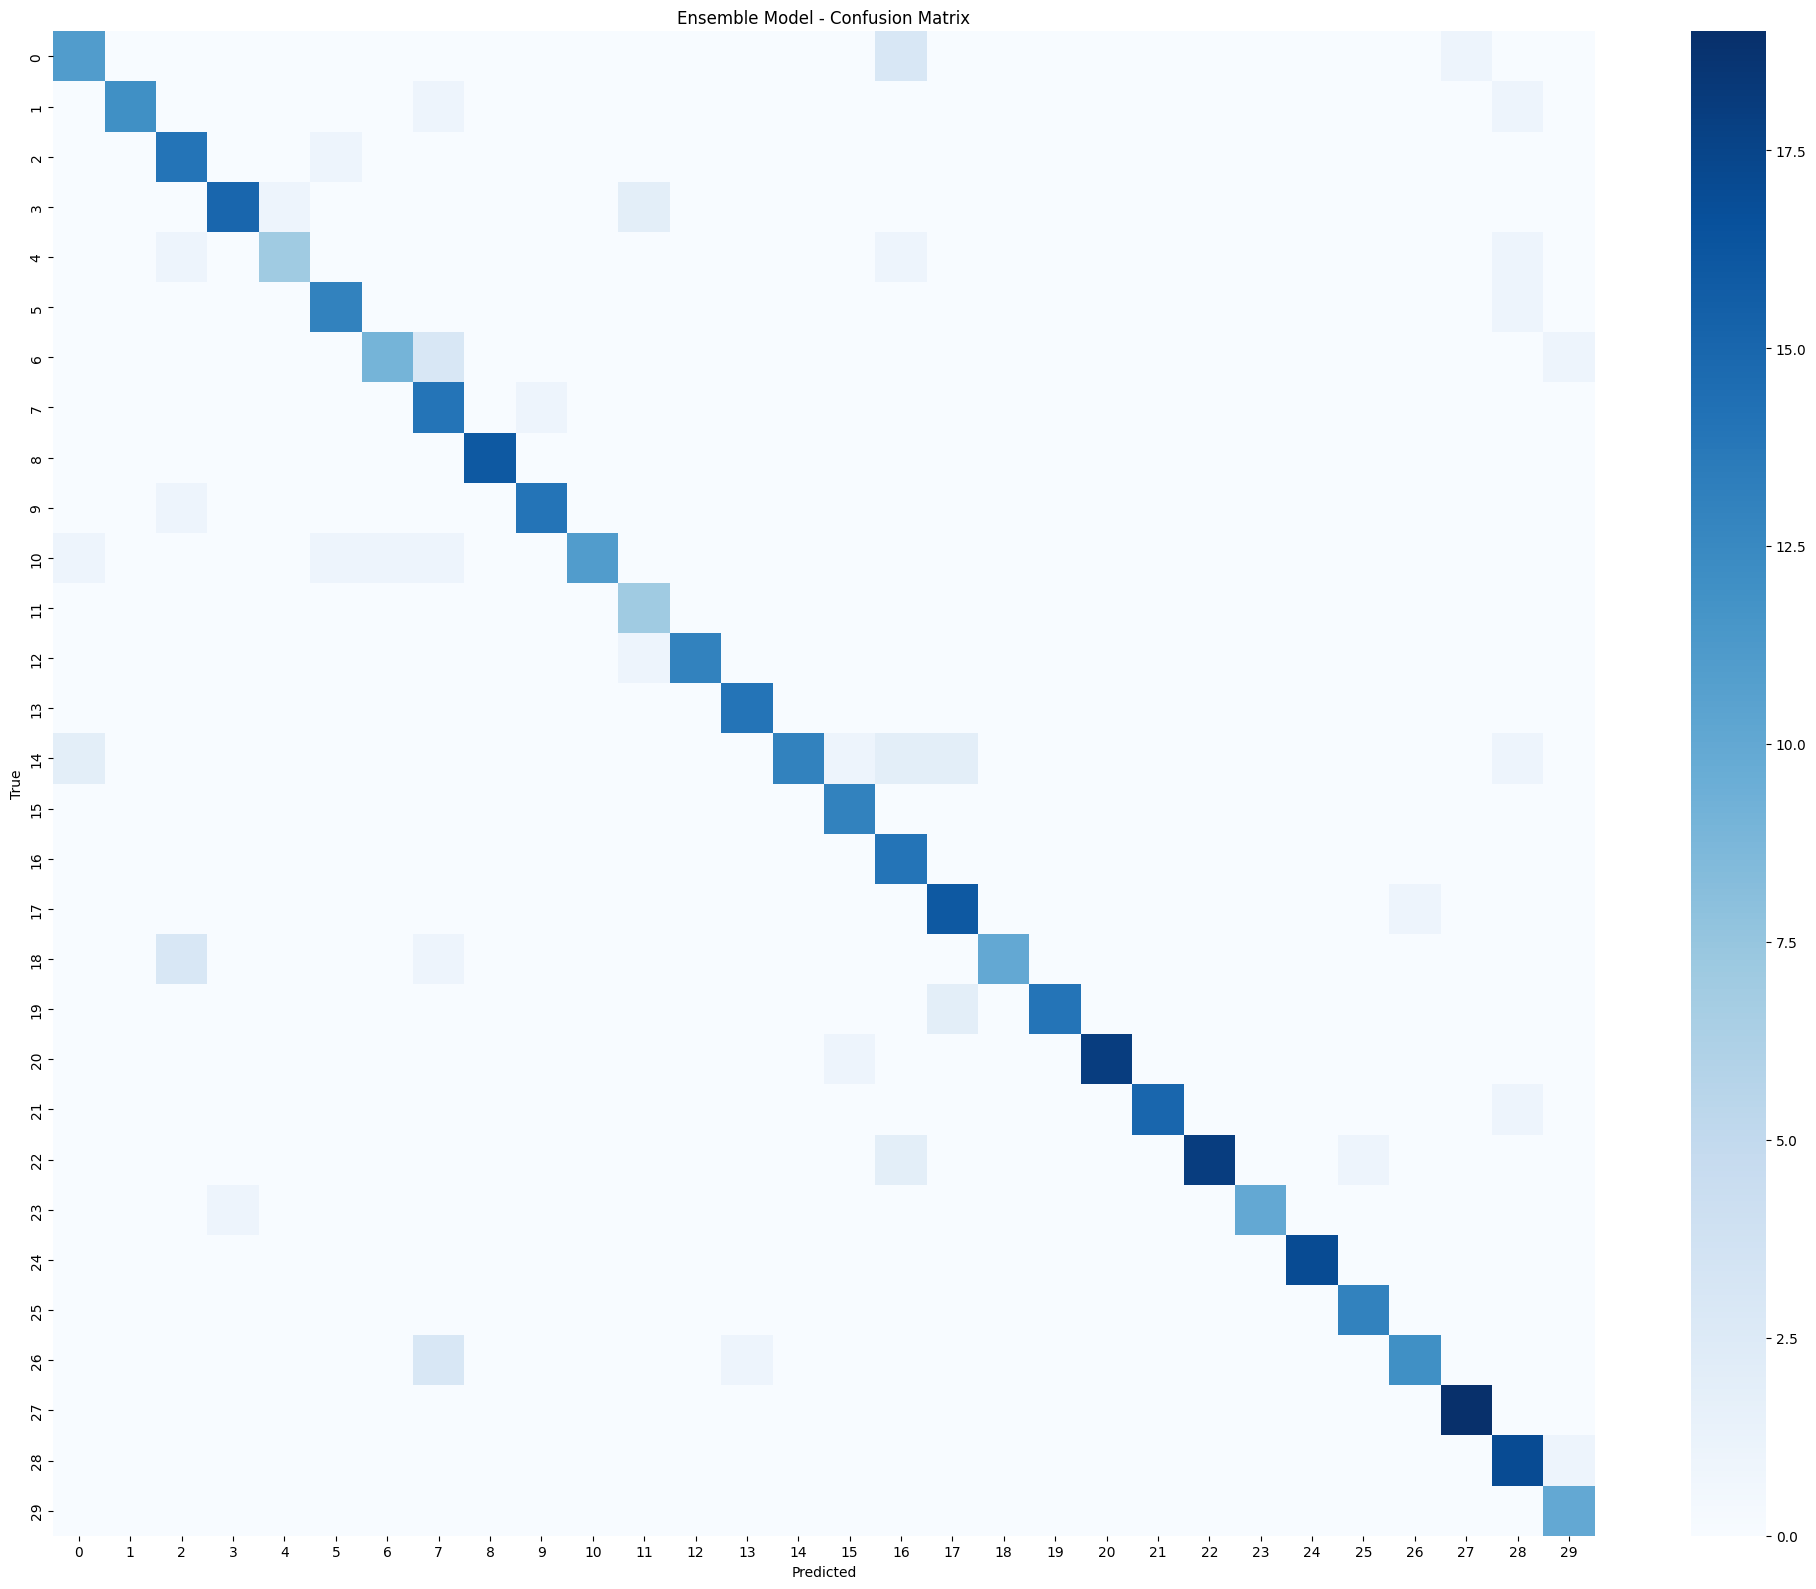


📊 DETAILED CLASSIFICATION REPORT - ENSEMBLE MODEL
              precision    recall  f1-score   support

           0      0.786     0.733     0.759        15
           1      1.000     0.857     0.923        14
           2      0.737     0.933     0.824        15
           3      0.938     0.833     0.882        18
           4      0.875     0.700     0.778        10
           5      0.867     0.929     0.897        14
           6      0.900     0.692     0.783        13
           7      0.609     0.933     0.737        15
           8      1.000     1.000     1.000        16
           9      0.933     0.933     0.933        15
          10      1.000     0.733     0.846        15
          11      0.700     1.000     0.824         7
          12      1.000     0.929     0.963        14
          13      0.933     1.000     0.966        14
          14      1.000     0.619     0.765        21
          15      0.867     1.000     0.929        13
          16      0.636     1.

In [15]:
# ============================================
# CELL 10: Evaluate Ensemble on Test Set
# ============================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_ensemble(ensemble_model, test_loader):
    """Evaluate ensemble model on test set"""
    ensemble_model.eval()
    all_preds = []
    all_labels = []

    # Also evaluate individual models for comparison
    image_only_preds = []
    numerical_only_preds = []

    with torch.no_grad():
        for images, numerical_feats, labels in tqdm(test_loader, desc="Evaluating"):
            images = images.to(config.DEVICE)
            numerical_feats = numerical_feats.to(config.DEVICE).float()
            labels = labels.to(config.DEVICE)

            # Ensemble predictions
            outputs = ensemble_model(images, numerical_feats)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Individual model predictions for comparison
            image_outputs = ensemble_model.image_model(images)
            image_preds = torch.argmax(image_outputs, dim=1)
            image_only_preds.extend(image_preds.cpu().numpy())

            if ensemble_model.use_mlp:
                numerical_outputs = ensemble_model.numerical_model(numerical_feats)
                numerical_preds = torch.argmax(numerical_outputs, dim=1)
                numerical_only_preds.extend(numerical_preds.cpu().numpy())

    # Calculate accuracies
    ensemble_acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100
    image_acc = (np.array(image_only_preds) == np.array(all_labels)).mean() * 100
    numerical_acc = (np.array(numerical_only_preds) == np.array(all_labels)).mean() * 100 if numerical_only_preds else 0



    print(f"\n{'='*60}")
    print(f"📊 TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"Ensemble Model (Image={config.IMAGE_WEIGHT}, Numerical={config.NUMERICAL_WEIGHT}):")
    print(f"   Accuracy: {ensemble_acc:.2f}%")
    print(f"\nIndividual Models:")
    print(f"   Image Only (Texture): {image_acc:.2f}%")
    if numerical_only_preds:
        print(f"   Numerical Only (Length+Width): {numerical_acc:.2f}%")

    # Confusion matrix for ensemble
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
    plt.title('Ensemble Model - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_DIR, 'ensemble_confusion_matrix.png'))
    plt.show()

    # Print detailed classification report
    print("\n" + "="*80)
    print("📊 DETAILED CLASSIFICATION REPORT - ENSEMBLE MODEL")
    print("="*80)
    print(classification_report(all_labels, all_preds,digits=3))



    return ensemble_acc, image_acc, numerical_acc

# Evaluate
ensemble_acc, image_acc, numerical_acc = evaluate_ensemble(ensemble_model, test_loader)

In [13]:
def evaluate_ensemble(ensemble_model, test_loader):
    """Evaluate ensemble model on test set"""
    ensemble_model.eval()
    all_preds = []
    all_labels = []

    image_only_preds = []
    numerical_only_preds = []

    with torch.no_grad():
        for images, numerical_feats, labels in tqdm(test_loader, desc="Evaluating"):
            images = images.to(config.DEVICE)
            numerical_feats = numerical_feats.to(config.DEVICE).float()
            labels = labels.to(config.DEVICE)

            outputs = ensemble_model(images, numerical_feats)
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Individual model predictions
            image_outputs = ensemble_model.image_model(images)
            image_preds = torch.argmax(image_outputs, dim=1)
            image_only_preds.extend(image_preds.cpu().numpy())

            if ensemble_model.use_mlp:
                numerical_outputs = ensemble_model.numerical_model(numerical_feats)
                numerical_preds = torch.argmax(numerical_outputs, dim=1)
                numerical_only_preds.extend(numerical_preds.cpu().numpy())

    # Convert to numpy
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate accuracies
    ensemble_acc = (all_preds == all_labels).mean() * 100
    image_acc = (np.array(image_only_preds) == all_labels).mean() * 100
    numerical_acc = (np.array(numerical_only_preds) == all_labels).mean() * 100 if numerical_only_preds else 0

    print(f"\n{'='*60}")
    print(f"📊 TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"Ensemble Model: {ensemble_acc:.2f}%")
    print(f"Image Only: {image_acc:.2f}%")
    print(f"Numerical Only: {numerical_acc:.2f}%")

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(20, 16))
    sns.heatmap(cm, annot=False, cmap='Blues', cbar=True)
    plt.title('Ensemble Model - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig(os.path.join(config.SAVE_DIR, 'ensemble_confusion_matrix.png'))
    plt.show()

    # CLASSIFICATION REPORT (even without class_names)
    print("\n" + "="*80)
    print("📊 CLASSIFICATION REPORT - ENSEMBLE MODEL")
    print("="*80)
    print(classification_report(all_labels, all_preds, digits=3))

    # PER-CLASS ACCURACY
    cm_matrix = confusion_matrix(all_labels, all_preds)
    per_class_acc = cm_matrix.diagonal() / cm_matrix.sum(axis=1)

    print("\n" + "="*60)
    print("📊 PER-CLASS ACCURACY")
    print("="*60)
    for i, acc in enumerate(per_class_acc):
        print(f"Class {i}: {acc:.4f} ({acc*100:.2f}%)")

    # If you have class_names, use them instead of Class i
    # Uncomment if you have class_names variable
    # if 'class_names' in globals():
    #     for i, acc in enumerate(per_class_acc):
    #         print(f"{class_names[i]}: {acc:.4f} ({acc*100:.2f}%)")

    return ensemble_acc, image_acc, numerical_acc

Evaluating: 100%|██████████| 8/8 [00:06<00:00,  1.28it/s]



📊 TEST SET RESULTS
Ensemble Model: 91.11%
Image Only: 66.44%
Numerical Only: 17.11%


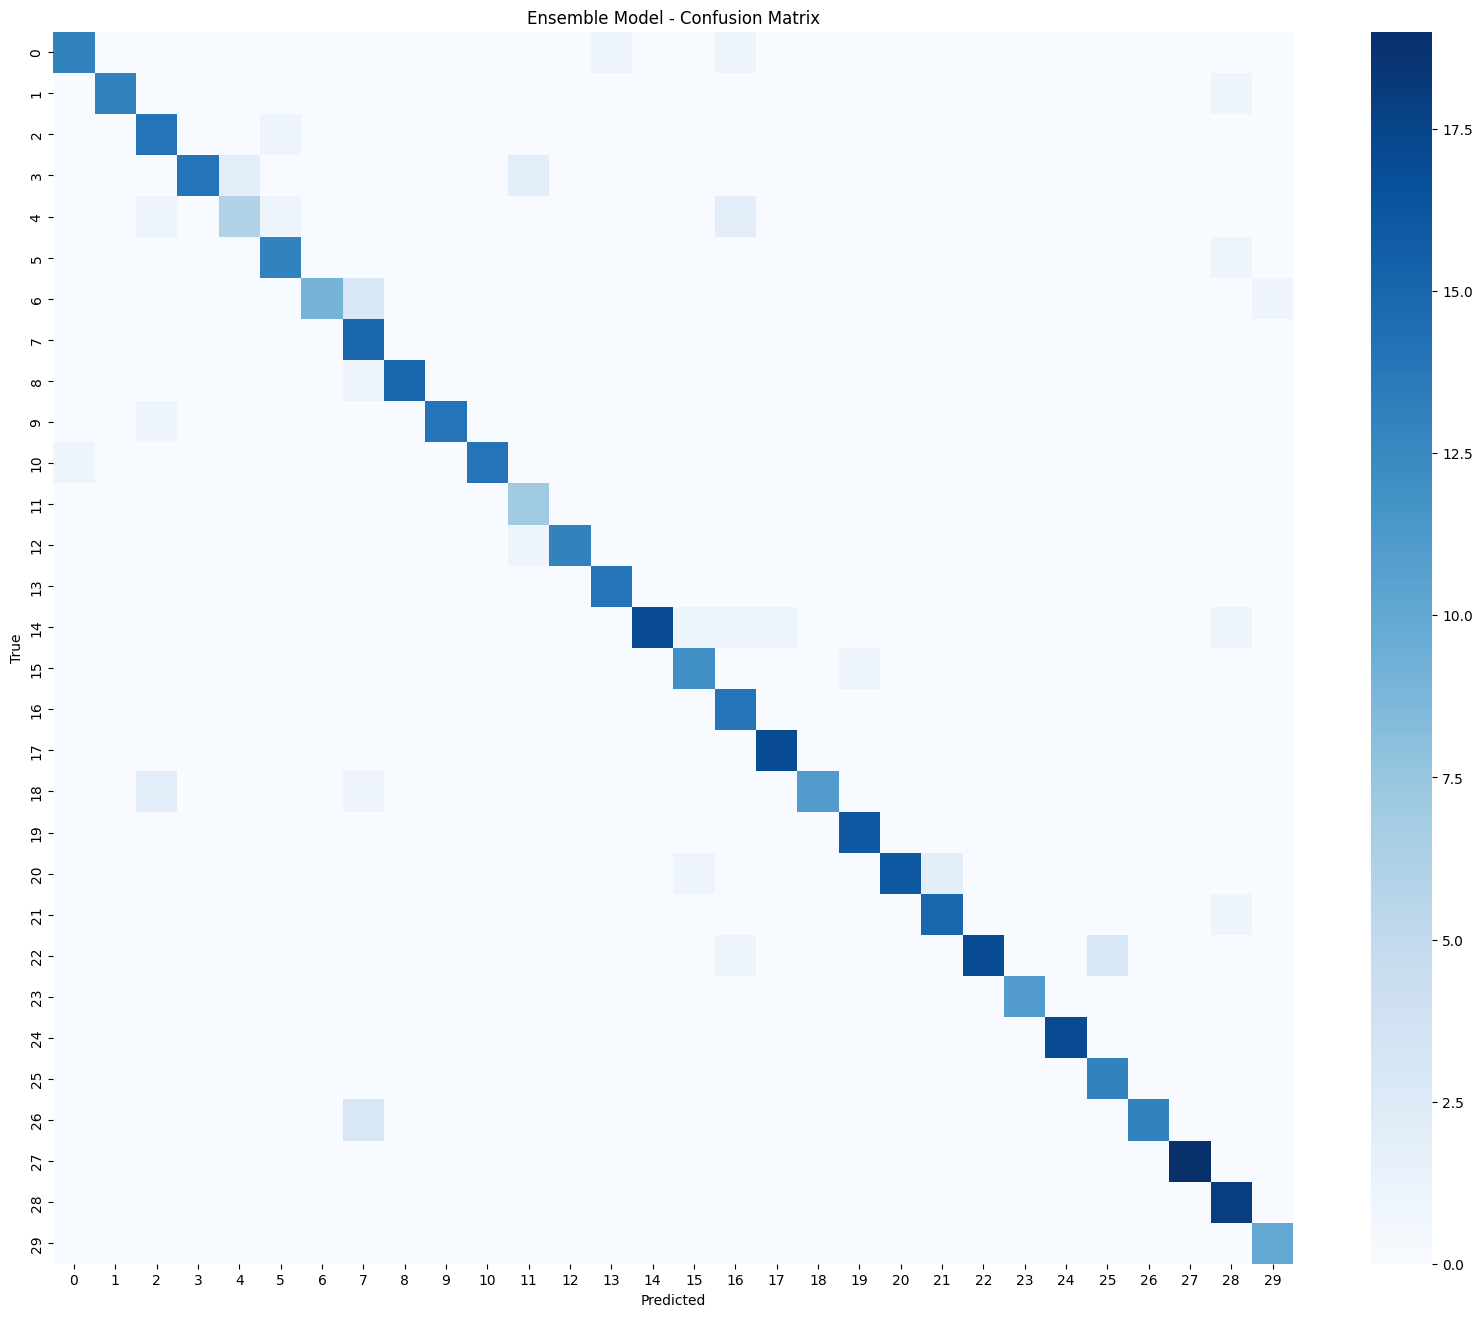


📊 CLASSIFICATION REPORT - ENSEMBLE MODEL
              precision    recall  f1-score   support

           0      0.929     0.867     0.897        15
           1      1.000     0.929     0.963        14
           2      0.778     0.933     0.848        15
           3      1.000     0.778     0.875        18
           4      0.750     0.600     0.667        10
           5      0.867     0.929     0.897        14
           6      1.000     0.692     0.818        13
           7      0.652     1.000     0.789        15
           8      1.000     0.938     0.968        16
           9      1.000     0.933     0.966        15
          10      1.000     0.933     0.966        15
          11      0.700     1.000     0.824         7
          12      1.000     0.929     0.963        14
          13      0.933     1.000     0.966        14
          14      1.000     0.810     0.895        21
          15      0.857     0.923     0.889        13
          16      0.737     1.000     0

In [14]:
e_acc, i_acc, n_acc = evaluate_ensemble(ensemble_model, test_loader)

In [ ]:
# ============================================
# CELL 11: Weight Optimization (Find Best Ensemble Weights)
# ============================================
def find_optimal_weights(ensemble_model, val_loader, step=0.1):
    """Find optimal ensemble weights through grid search"""
    print("\n🔍 Finding optimal ensemble weights...")

    best_weight = 0.5
    best_accuracy = 0

    weights = np.arange(0, 1.1, step)
    results = []

    for img_weight in weights:
        num_weight = 1 - img_weight

        # Set weights
        ensemble_model.set_weights(img_weight, num_weight)

        # Evaluate
        ensemble_model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, numerical_feats, labels in val_loader:
                images = images.to(config.DEVICE)
                numerical_feats = numerical_feats.to(config.DEVICE).float()
                labels = labels.to(config.DEVICE)

                outputs = ensemble_model(images, numerical_feats)
                preds = torch.argmax(outputs, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        acc = (np.array(all_preds) == np.array(all_labels)).mean() * 100
        results.append((img_weight, num_weight, acc))

        if acc > best_accuracy:
            best_accuracy = acc
            best_weight = img_weight

        print(f"   Image={img_weight:.1f}, Numerical={num_weight:.1f} → Acc={acc:.2f}%")

    print(f"\n✅ Optimal weights found:")
    print(f"   Image weight: {best_weight:.1f}")
    print(f"   Numerical weight: {1-best_weight:.1f}")
    print(f"   Best accuracy: {best_accuracy:.2f}%")

    # Plot weight vs accuracy
    plt.figure(figsize=(8, 5))
    weights_img = [r[0] for r in results]
    accuracies = [r[2] for r in results]
    plt.plot(weights_img, accuracies, 'b-o')
    plt.xlabel('Image Model Weight')
    plt.ylabel('Validation Accuracy (%)')
    plt.title('Ensemble Weight Optimization')
    plt.grid(True)
    plt.axvline(x=best_weight, color='r', linestyle='--', label=f'Optimal: {best_weight:.1f}')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(config.SAVE_DIR, 'weight_optimization.png'))
    plt.show()

    return best_weight, best_accuracy

# Run weight optimization (optional - comment out if not needed)
# optimal_weight, best_acc = find_optimal_weights(ensemble_model, val_loader, step=0.1)
# config.IMAGE_WEIGHT = optimal_weight
# config.NUMERICAL_WEIGHT = 1 - optimal_weight

In [ ]:
# ============================================
# CELL 12: Save Final Ensemble Model
# ============================================
# Save final model to Google Drive
!mkdir -p /content/drive/MyDrive/ensemble_leaf_backup/

# Save ensemble model
torch.save({
    'ensemble_state_dict': ensemble_model.state_dict(),
    'image_weight': config.IMAGE_WEIGHT,
    'numerical_weight': config.NUMERICAL_WEIGHT,
    'scaler': scaler,
    'class_to_idx': class_to_idx,
    'final_test_accuracy': ensemble_acc
}, '/content/drive/MyDrive/ensemble_leaf_backup/final_ensemble_model.pth')

# Save results
import json
results = {
    'ensemble_accuracy': float(ensemble_acc),
    'image_only_accuracy': float(image_acc),
    'numerical_only_accuracy': float(numerical_acc),
    'image_weight': config.IMAGE_WEIGHT,
    'numerical_weight': config.NUMERICAL_WEIGHT,
    'num_classes': config.NUM_CLASSES
}

with open('/content/drive/MyDrive/ensemble_leaf_backup/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*60}")
print(f"✅ FINAL ENSEMBLE MODEL SAVED")
print(f"{'='*60}")
print(f"📍 Location: /content/drive/MyDrive/ensemble_leaf_backup/")
print(f"📊 Final Test Accuracy: {ensemble_acc:.2f}%")
print(f"⚖️ Ensemble Weights: Image={config.IMAGE_WEIGHT}, Numerical={config.NUMERICAL_WEIGHT}")
print(f"{'='*60}")


✅ FINAL ENSEMBLE MODEL SAVED
📍 Location: /content/drive/MyDrive/ensemble_leaf_backup/
📊 Final Test Accuracy: 95.11%
⚖️ Ensemble Weights: Image=0.5, Numerical=0.5
